In [1]:
import gymnasium as gym
import numpy as np

class missile_interception_3d(gym.Env):
    def __init__(self, enemy_mode="ballistic"):
        assert enemy_mode in ("ballistic", "static")
        self.enemy_mode = enemy_mode

        # 1. Define Action Space: magnitude + direction on unit circle (cos, sin)
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        # 2. Define Observation Space (16D ego-frame, no actuator state)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(16,), dtype=np.float32)

        self.np_random = np.random.RandomState()
        
        # 3. Time Settings
        self.dt_act = 0.1             
        self.n_substeps = 1      
        self.dt_sim = self.dt_act / self.n_substeps 
        self.t_max = 80.0
        self.episode_cap_time = 80.0

        # 4. Physical Limits
        self.a_max = 450.0   # Max G-force (m/s^2) ~35G
        self.g = 9.81        
        self.collision_radius = 5.0   # easier for sparse learning

        # Small geometry so sparse RL can bootstrap (random success plausible)
        self.p_easy = 1.0                   
        self.range_min = 1500.0           
        self.range_easy_max = 4000.0     
        self.range_hard_max = 2500.0

        self.targetbox_x_min = -5500
        self.targetbox_x_max = 5500
        self.targetbox_y_min = -5500
        self.targetbox_y_max = 5500

        # ---- New ZEM reward parameters ----
        self.d_scale = 100.0      # will tune later using ProNav statistics
        self.v_scale = 1000.0
        self.eta_close = 0.1

        self.r_hit_bonus = 25.0
        self.r_timeout_pen = 25.0
        self.r_enemy_ground_pen = 25.0
        self.r_def_ground_pen = 40.0

        # episode diagnostics (no thresholds)
        self.ep_dca_pos_steps = 0          # count(delta_dca > 0)
        self.ep_vclose_pos_steps = 0       # count(v_close > 0)

    def generate_enemy_missile(self):
        if self.np_random.rand() < self.p_easy:
            self.range_max_used = self.range_easy_max
        else:
            self.range_max_used = self.range_hard_max

        range_min = self.range_min
        self.attack_target_x = self.np_random.uniform(self.targetbox_x_min, self.targetbox_x_max)
        self.attack_target_y = self.np_random.uniform(self.targetbox_y_min, self.targetbox_y_max)
        self.enemy_launch_angle = self.np_random.uniform(0, 2 * np.pi)
        self.enemy_theta = self.np_random.uniform(np.deg2rad(10), np.deg2rad(25)) 

        self.range_max_used = max(self.range_max_used, range_min + 1.0)
        lower_limit = np.sqrt((range_min * self.g) / np.sin(2 * self.enemy_theta))
        upper_limit = np.sqrt((self.range_max_used * self.g) / np.sin(2 * self.enemy_theta))
        lower_limit = max(lower_limit, 250.0)
        upper_limit = min(upper_limit, 600.0)
        self.enemy_initial_velocity = self.np_random.uniform(lower_limit, upper_limit)
        ground_range = (
            self.enemy_initial_velocity * np.cos(self.enemy_theta)
            * (2 * self.enemy_initial_velocity * np.sin(self.enemy_theta) / self.g)
        )
        self.enemy_t_flight = 2.0 * self.enemy_initial_velocity * np.sin(self.enemy_theta) / self.g

        self.enemy_launch_x = self.attack_target_x + ground_range * np.cos(self.enemy_launch_angle)
        self.enemy_launch_y = self.attack_target_y + ground_range * np.sin(self.enemy_launch_angle)
        self.enemy_z = 0
        self.enemy_x = self.enemy_launch_x
        self.enemy_y = self.enemy_launch_y
        self.enemy_pos = np.array([self.enemy_x, self.enemy_y, self.enemy_z], dtype=np.float32)
        self.enemy_azimuth = (self.enemy_launch_angle + np.pi) % (2 * np.pi)

        if self.enemy_mode == "static":
            # Freeze enemy at a random mid-flight point of its ballistic trajectory
            vel0 = np.array([
                self.enemy_initial_velocity * np.cos(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_theta),
            ], dtype=np.float64)
            g_vec = np.array([0.0, 0.0, -self.g], dtype=np.float64)
            t_flight = 2.0 * self.enemy_initial_velocity * np.sin(self.enemy_theta) / self.g
            t_sample = self.np_random.uniform(0.25, 0.75) * t_flight
            pos0 = self.enemy_pos.astype(np.float64)
            self.enemy_pos = (pos0 + vel0 * t_sample + 0.5 * g_vec * (t_sample ** 2)).astype(np.float32)
            self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos

    def generate_defense_missile(self):
        # Spawn defender near the defended target (not random over whole map)
        radius = self.np_random.uniform(200.0, 800.0)
        angle = self.np_random.uniform(0, 2 * np.pi)
        self.defense_launch_x = self.attack_target_x + radius * np.cos(angle)
        self.defense_launch_y = self.attack_target_y + radius * np.sin(angle)

        dx = self.enemy_x - self.defense_launch_x
        dy = self.enemy_y - self.defense_launch_y
        az_nominal = np.arctan2(dy, dx)
        self.az_nominal = az_nominal

        # --- Misalignment: interceptor initially points roughly toward target ---
        az_noise_deg = 5.0
        az_noise = self.np_random.uniform(-np.deg2rad(az_noise_deg), +np.deg2rad(az_noise_deg))
        self.defense_azimuth = az_nominal + az_noise

        self.defense_theta = np.deg2rad(25.0)

        base_velocity = 800.0
        self.defense_initial_velocity = base_velocity

        self.defense_x = self.defense_launch_x
        self.defense_y = self.defense_launch_y
        self.defense_z = 0.0
        self.defense_pos = np.array([self.defense_x, self.defense_y, self.defense_z], dtype=np.float32)
    
    def _smoothstep(self, x: float) -> float:
        """Smooth ramp 0->1 with zero slope at ends, clamps outside [0,1]"""
        x = float(np.clip(x, 0.0, 1.0))
        return x * x * (3.0 - 2.0 * x)

    def _decode_action(self, a):
        """
        a = [m_raw, c_raw, s_raw] in [-1,1]^3
        Returns: (u_right, u_up) in [-1,1] with sqrt(u_right^2 + u_up^2) <= 1
        """
        a = np.asarray(a, dtype=np.float32)
        m_raw, c_raw, s_raw = float(a[0]), float(a[1]), float(a[2])

        m = 0.5 * (m_raw + 1.0)   # [-1,1] -> [0,1]

        v = np.array([c_raw, s_raw], dtype=np.float32)
        n = float(np.linalg.norm(v))
        if n < 1e-6:
            dir2 = np.array([1.0, 0.0], dtype=np.float32)
        else:
            dir2 = v / n

        u_right = float(m * dir2[0])
        u_up    = float(m * dir2[1])
        return np.array([u_right, u_up], dtype=np.float32)

    def calculate_pronav(self):
        eps = 1e-9

        # Relative geometry (use float64 for stability)
        r = (self.enemy_pos - self.defense_pos).astype(np.float64)
        v = self.defense_vel.astype(np.float64)
        vrel = (self.enemy_vel - self.defense_vel).astype(np.float64)

        R = float(np.linalg.norm(r)) + eps
        V = float(np.linalg.norm(v)) + eps

        rhat = r / R
        vhat = v / V

        # Heading error alpha = angle between velocity direction and LOS direction
        cosang = float(np.clip(np.dot(vhat, rhat), -1.0, 1.0))
        alpha = float(np.arccos(cosang))  # radians

        # LOS angular rate omega (world frame)
        omega = np.cross(r, vrel) / (float(np.dot(r, r)) + eps)
        omega_mag = float(np.linalg.norm(omega))

        # Closing speed (positive => closing)
        vc = -float(np.dot(r, vrel)) / R

        # --- PN term ---
        N = 3.0
        a_pn = N * vc * np.cross(omega, rhat)  # lateral accel in world frame

        # --- Acquisition term (turn-to-LOS) ---
        # Perpendicular component of LOS relative to forward direction
        rhat_perp = rhat - float(np.dot(rhat, vhat)) * vhat
        nperp = float(np.linalg.norm(rhat_perp))

        if nperp < 1e-8:
            a_acq = np.zeros(3, dtype=np.float64)
        else:
            rhat_perp /= nperp  # unit sideways "turn toward LOS" direction

            # Curvature-based magnitude: ~k * V^2 / R, saturate later via a_max
            k_acq = 5.0  # try 3.0–8.0
            a_acq = k_acq * (V * V / R) * rhat_perp

        # --- Blend weight w: 0 => pure PN, 1 => pure acquisition ---

        # Alpha-based weight (dominant)
        alpha_on   = np.deg2rad(20.0)   # start blending earlier
        alpha_full = np.deg2rad(55.0)

        x_alpha = (alpha - alpha_on) / (alpha_full - alpha_on + eps)
        w_alpha = self._smoothstep(x_alpha)

        # Omega-based modifier (only boosts acquisition when PN is sleepy)
        omega_full = 0.00
        omega_on   = 0.05   # <-- key: less brittle than 0.02

        x_omega = (omega_on - omega_mag) / (omega_on - omega_full + eps)
        w_omega = self._smoothstep(x_omega)

        # Robust combine: alpha dominates; omega can't fully shut it off
        w = w_alpha * (0.25 + 0.75 * w_omega)

        # Optional: if not closing, force strong acquisition
        if vc <= 0.0:
            w = max(w, 0.9)

        a_ideal = (1.0 - w) * a_pn + w * a_acq

        # Project into your lateral control basis (right/up) and normalize by a_max
        # Action is lateral body acceleration; gravity applies as world force.
        # so ProNav outputs desired NET lateral accel (same semantics as PPO)
        forward, right, up = self._compute_lateral_basis(self.defense_vel)
        a_right = float(np.dot(a_ideal, right))
        a_up    = float(np.dot(a_ideal, up))

        u_raw = np.array([a_right / self.a_max, a_up / self.a_max], dtype=np.float32)
        self._pronav_u_raw = u_raw.copy()
        u = np.clip(u_raw, -1.0, 1.0)

        # debug instrumentation
        a_pn_mag = float(np.linalg.norm(a_pn))
        a_acq_mag = float(np.linalg.norm(a_acq))
        a_cmd_mag = float(np.linalg.norm(a_ideal))
        return pronav_to_polar_action(float(u[0]), float(u[1]))
    
    def _segment_sphere_intersect(self, r0, r1, r_hit):
        dr = r1 - r0
        dr_norm_sq = float(np.dot(dr, dr))
        if dr_norm_sq < 1e-12:
            return float(np.dot(r0, r0)) <= r_hit * r_hit
        s_star = -float(np.dot(r0, dr)) / dr_norm_sq
        s_star = max(0.0, min(1.0, s_star))
        r_closest = r0 + s_star * dr
        return float(np.dot(r_closest, r_closest)) <= r_hit * r_hit
    
    def _get_obs(self):
        eps = 1e-9

        # World-frame relative state
        r_world = (self.enemy_pos - self.defense_pos).astype(np.float64)
        vrel_world = (self.enemy_vel - self.defense_vel).astype(np.float64)

        # Local basis from defense velocity (world frame unit vectors)
        forward, right, up = self._compute_lateral_basis(self.defense_vel)

        # ===============================
        # 1) Ego-frame (body-frame) r and vrel
        # ===============================
        r_body = np.array([
            float(np.dot(r_world, forward)),
            float(np.dot(r_world, right)),
            float(np.dot(r_world, up)),
        ], dtype=np.float64)

        vrel_body = np.array([
            float(np.dot(vrel_world, forward)),
            float(np.dot(vrel_world, right)),
            float(np.dot(vrel_world, up)),
        ], dtype=np.float64)

        # Normalize r_body / vrel_body
        pos_scale = float(self.range_easy_max)   # 10 km
        vel_scale = 2500.0                        # max vrel ~2300 m/s in Stage-1

        r_body_n = (r_body / (pos_scale + eps)).astype(np.float32)
        vrel_body_n = (vrel_body / (vel_scale + eps)).astype(np.float32)

        # ===============================
        # 2) Scalar helpers
        # ===============================
        dist = float(np.linalg.norm(r_world)) + 1e-6
        v_close = -float(np.dot(r_world, vrel_world)) / dist  # positive when closing

        dist_n = np.float32(np.clip(dist / 50_000.0, 0.0, 4.0))
        vclose_n = np.float32(np.clip(v_close / 2000.0, -2.0, 2.0))
        dist_vclose_feat = np.array([dist_n, vclose_n], dtype=np.float32)

        # Defense own vertical state (keep for ground constraint)
        def_z_n = np.float32(np.clip(self.defense_pos[2] / 15_000.0, -1.0, 2.0))
        def_vz_n = np.float32(np.clip(self.defense_vel[2] / 1200.0, -2.0, 2.0))
        def_state_feat = np.array([def_z_n, def_vz_n], dtype=np.float32)

        # ===============================
        # 4) Keep your geometry features (consistent with ego-frame)
        # ===============================
        dist_body = float(np.linalg.norm(r_body)) + 1e-6

        # LOS lateral projections in body frame
        los_right = float(r_body[1] / dist_body)
        los_up    = float(r_body[2] / dist_body)

        # LOS rate omega in body frame: omega = (r x vrel)/||r||^2
        dist2_body = float(np.dot(r_body, r_body)) + eps
        omega_body = np.cross(r_body, vrel_body) / dist2_body

        omega_right = float(omega_body[1])
        omega_up    = float(omega_body[2])

        omega_scale = 2.0
        omega_right_n = float(np.clip(omega_right / omega_scale, -2.0, 2.0))
        omega_up_n    = float(np.clip(omega_up / omega_scale, -2.0, 2.0))

        geom_feat = np.array([los_right, los_up, omega_right_n, omega_up_n], dtype=np.float32)

        # ===============================
        # 5) NEW: kinematics garnish
        # ===============================
        V_def = float(np.linalg.norm(self.defense_vel))
        V_def_n = np.float32(np.clip(V_def / 1500.0, 0.0, 3.0))
        forward_z = np.float32(float(forward[2]))               # dot(forward, world_up) since world_up=[0,0,1]

        kin_feat = np.array([V_def_n, forward_z], dtype=np.float32)

        # Final obs (16D, no actuator state)
        obs = np.concatenate(
            [r_body_n, vrel_body_n, dist_vclose_feat, def_state_feat, geom_feat, kin_feat],
            axis=0
        ).astype(np.float32)

        return obs

    def _compute_lateral_basis(self, velocity):
        """
        Horizon-stable basis:
          forward = along velocity
          right   = world_up x forward  (horizontal right)
          up      = forward x right     (completes orthonormal frame)
        This keeps 'up' as close to world-up as possible and avoids weird twisting.
        """
        speed = float(np.linalg.norm(velocity))
        if speed < 1.0:
            forward = np.array([1.0, 0.0, 0.0], dtype=np.float32)
        else:
            forward = (velocity / speed).astype(np.float32)

        world_up = np.array([0.0, 0.0, 1.0], dtype=np.float32)

        # right = world_up x forward
        right_raw = np.cross(world_up, forward)
        rnorm = float(np.linalg.norm(right_raw))

        # If forward is near world_up, right_raw ~ 0. Pick a consistent fallback.
        if rnorm < 1e-6:
            # Choose a fixed "north" axis in world XY and build right from that
            # This prevents random spinning when vertical.
            north = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            right_raw = np.cross(north, forward)
            rnorm = float(np.linalg.norm(right_raw))
            if rnorm < 1e-6:
                north = np.array([0.0, 1.0, 0.0], dtype=np.float32)
                right_raw = np.cross(north, forward)
                rnorm = float(np.linalg.norm(right_raw))

        right = (right_raw / (rnorm + 1e-9)).astype(np.float32)

        # up = forward x right (not right x forward)
        up_raw = np.cross(forward, right)
        up = (up_raw / (float(np.linalg.norm(up_raw)) + 1e-9)).astype(np.float32)

        return forward, right, up

    def step(self, action):
        if getattr(self, "done", False):
            return self._get_obs(), 0.0, True, False, {"event": "called_step_after_done", "dist": float(np.linalg.norm(self.enemy_pos - self.defense_pos)), "mag_exec": float(np.nan)}
        
        action = np.clip(action, -1.0, 1.0).astype(np.float32)
        action2 = self._decode_action(action)  # 3D polar -> 2D (right, up), ||.|| <= 1
        mag_exec = float(np.linalg.norm(action2))
        assert mag_exec <= 1.0001, f"_decode_action broke invariant: ||action2|| = {mag_exec}"
        
        # Update episode trackers
        self.ep_max_action_mag = max(self.ep_max_action_mag, mag_exec)

        terminated = False
        truncated = False
        event = "running"
        
        for _ in range(self.n_substeps):
            dt = self.dt_sim
            enemy_pos_old = self.enemy_pos.copy()
            defense_pos_old = self.defense_pos.copy()
            
            forward, right, up = self._compute_lateral_basis(self.defense_vel)
            g_vec = np.array([0.0, 0.0, -self.g], dtype=np.float32)

            # Pure commanded acceleration in body right/up
            a_cmd = (action2[0] * self.a_max) * right + (action2[1] * self.a_max) * up

            # Physics: command + gravity
            self.defense_vel += (a_cmd + g_vec) * dt
            self.defense_pos += self.defense_vel * dt
            self.defense_x, self.defense_y, self.defense_z = self.defense_pos
            
            # Enemy missile: ballistic (gravity only) OR frozen (static mode)
            if self.enemy_mode == "ballistic":
                self.enemy_vel += g_vec * dt
                self.enemy_pos += self.enemy_vel * dt
                self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos
            self.t += dt
            
            r0 = enemy_pos_old - defense_pos_old
            r1 = self.enemy_pos - self.defense_pos

            # Closest point along segment (same geometry as hit detector)
            dr = r1 - r0
            dr_norm_sq = np.dot(dr, dr)
            if dr_norm_sq > 1e-12:
                s_star = -np.dot(r0, dr) / dr_norm_sq
                s_star = np.clip(s_star, 0.0, 1.0)
                r_closest = r0 + s_star * dr
                dist_seg = np.linalg.norm(r_closest)
            else:
                dist_seg = np.linalg.norm(r0)
            self.ep_min_dist = min(self.ep_min_dist, float(dist_seg))

            if self._segment_sphere_intersect(r0, r1, self.collision_radius):
                self.success = True
                terminated = True
                self.done = True
                event = "hit"
                self.time_to_hit = float(self.t)
                self.terminal_event = "hit"
                break
            
            # --- Only real physics terminals ---
            if self.defense_pos[2] < 0.0:
                terminated = True
                self.done = True
                event = "defense_ground"
                self.terminal_event = event
                break

            if self.enemy_mode == "ballistic" and self.enemy_pos[2] < 0.0:
                terminated = True
                self.done = True
                event = "enemy_ground"
                self.terminal_event = event
                break

            if self.enemy_mode == "static" and self.t >= self.episode_cap_time:
                truncated = True
                self.done = True
                event = "episode_cap"
                self.terminal_event = event
                break

            # --- Debug safety fuse (not a "task" terminal) ---
            if self.t >= self.t_max:
                truncated = True
                self.done = True
                event = "debug_cap"
                self.terminal_event = event
                break

        obs = self._get_obs()
        dist_after = float(np.linalg.norm(self.enemy_pos - self.defense_pos))
        self.min_dist = min(getattr(self, "min_dist", float("inf")), dist_after)

        # ==========================
        # Range delta (real geometry)
        # ==========================
        if getattr(self, "prev_dist", None) is None:
            dist_prev = dist_after
        else:
            dist_prev = float(self.prev_dist)

        delta_dist = dist_prev - dist_after  # >0 means we got closer in real range
        self.prev_dist = dist_after

        # ==========================================
        # ZEM-style geometry reward (with debug)
        # ==========================================
        eps = 1e-9
        r = (self.enemy_pos - self.defense_pos).astype(np.float64)
        vrel = (self.enemy_vel - self.defense_vel).astype(np.float64)

        r_norm = float(np.linalg.norm(r)) + eps
        r_norm_sq = float(np.dot(r, r)) + eps
        vrel_norm_sq = float(np.dot(vrel, vrel)) + eps
        dot_r_v = float(np.dot(r, vrel))

        # Raw time-to-closest-approach (can be <0 or huge)
        t_star_raw = -dot_r_v / vrel_norm_sq

        # Clip horizon
        t_cap = 10.0
        t_star_clipped = float(np.clip(t_star_raw, 0.0, t_cap))

        hit_t0   = (t_star_raw <= 0.0)
        hit_tcap = (t_star_raw >= t_cap)

        # Predicted closest approach vector and distance
        r_star = r + vrel * t_star_clipped
        d_ca = float(np.linalg.norm(r_star))

        # Previous d_ca (for delta)
        if self.prev_d_ca is None:
            d_ca_prev = d_ca
        else:
            d_ca_prev = float(self.prev_d_ca)

        delta_dca = d_ca_prev - d_ca
        self.prev_d_ca = d_ca

        # Count "did d_ca improve at all?"
        if delta_dca > 0.0:
            self.ep_dca_pos_steps += 1

        self.ep_total_steps += 1

        # LOS angular rate (world)
        omega_world = np.cross(r, vrel) / r_norm_sq
        omega_mag = float(np.linalg.norm(omega_world))

        # Closing speed (positive is closing)
        v_close = -dot_r_v / r_norm

        # Count "are we closing at all?"
        if v_close > 0.0:
            self.ep_vclose_pos_steps += 1

        if t_star_clipped < 2.0:
            self.ep_omega_terminal_samples.append(omega_mag)

        # ======================================
        # SPARSE TERMINAL REWARD ONLY (hit=+1, else=0)
        # No penalties — maximize P(hit)
        # ======================================
        reward = 1.0 if event == "hit" else 0.0

        if terminated or truncated:
            self.terminal_event = event

        steps = self.ep_total_steps
        dca_pos_ratio = (self.ep_dca_pos_steps / steps) if steps > 0 else 0.0
        vclose_pos_ratio = (self.ep_vclose_pos_steps / steps) if steps > 0 else 0.0

        v_def = self.defense_vel.astype(np.float64)
        V_def = float(np.linalg.norm(v_def)) + 1e-9
        fwd_z = float(self._compute_lateral_basis(self.defense_vel)[0][2])

        info = {
            "event": event,
            "t": float(self.t),
            "dist": float(dist_after),
            "closing": float(v_close),
            "reward": float(reward),
            "mag_exec": float(mag_exec),
            "defense_z": float(self.defense_pos[2]),
            "defense_vz": float(self.defense_vel[2]),
            "defense_speed": float(V_def),
            "forward_z": float(fwd_z),
            "delta_dca": float(delta_dca),
            "dca_pos_steps": int(self.ep_dca_pos_steps),
            "dca_pos_ratio": float(dca_pos_ratio),
            "vclose_pos_steps": int(self.ep_vclose_pos_steps),
            "vclose_pos_ratio": float(vclose_pos_ratio),
            "d_ca": float(d_ca),
            "t_star": float(t_star_clipped),
        }
        info.update({
            "dist_prev": float(dist_prev),
            "delta_dist": float(delta_dist),
            "t_cap": float(t_cap),
            "t_star_raw": float(t_star_raw),
            "t_star_hit0": bool(hit_t0),
            "t_star_hitcap": bool(hit_tcap),
            "dot_r_vrel": float(dot_r_v),
            "vrel_norm_sq": float(vrel_norm_sq),
            "r_norm": float(r_norm),
            "omega_mag": float(omega_mag),
            "r_star_x": float(r_star[0]),
            "r_star_y": float(r_star[1]),
            "r_star_z": float(r_star[2]),
        })
        if terminated or truncated:
            d_min = float(self.ep_min_dist)
            hit = (event == "hit")
            info["hit"] = hit
            info["miss_distance"] = d_min
            info["min_dist"] = d_min
            info["max_action_mag"] = float(self.ep_max_action_mag)
            info["time_to_hit"] = float(self.time_to_hit) if self.time_to_hit is not None else np.nan
            info["los_terminal_p95"] = float(np.percentile(self.ep_omega_terminal_samples, 95)) if self.ep_omega_terminal_samples else np.nan
        return obs, reward, terminated, truncated, info

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None: self.np_random = np.random.RandomState(seed)
        self.done = False
        self.success = False
        self.t = 0.0
        self._dbg_count = 0
        self.generate_enemy_missile()
        self.generate_defense_missile()
        
        self.defense_vel = np.array([
            self.defense_initial_velocity * np.cos(self.defense_azimuth) * np.cos(self.defense_theta),
            self.defense_initial_velocity * np.sin(self.defense_azimuth) * np.cos(self.defense_theta),
            self.defense_initial_velocity * np.sin(self.defense_theta)
        ], dtype=np.float32)
        
        if self.enemy_mode == "ballistic":
            self.enemy_vel = np.array([
                self.enemy_initial_velocity * np.cos(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_azimuth) * np.cos(self.enemy_theta),
                self.enemy_initial_velocity * np.sin(self.enemy_theta)
            ], dtype=np.float32)
        else:
            self.enemy_vel = np.zeros(3, dtype=np.float32)
        
        self.defense_pos = np.array([self.defense_x, self.defense_y, self.defense_z], dtype=np.float32)

        # enemy_pos: ballistic = rebuild from launch coords; static = keep mid-flight sample from generate_enemy_missile
        if self.enemy_mode == "ballistic":
            self.enemy_pos = np.array([self.enemy_x, self.enemy_y, self.enemy_z], dtype=np.float32)
        else:
            self.enemy_x, self.enemy_y, self.enemy_z = self.enemy_pos

        d0 = float(np.linalg.norm(self.enemy_pos - self.defense_pos))
        Vd = float(np.linalg.norm(self.defense_vel)) + 1e-6
        if self.enemy_mode in ("static", "linear"):
            self.t_max = self.episode_cap_time
        elif self.enemy_mode == "ballistic":
            self.t_max = self.enemy_t_flight  # exact physics cap
        self.min_dist = d0
        self.ep_min_dist = d0
        self.ep_max_action_mag = 0.0
        self.time_to_hit = None
        self.terminal_event = "running"
        self.prev_d_ca = None
        self.prev_dist = None
        self.ep_dca_pos_steps = 0
        self.ep_vclose_pos_steps = 0
        self.ep_total_steps = 0
        self.ep_omega_terminal_samples = []
        
        return self._get_obs(), {}


def pronav_to_polar_action(u_right, u_up):
    """Convert old-style 2D (right, up) action to new 3D polar (m_raw, c_raw, s_raw)."""
    u = np.array([u_right, u_up], dtype=np.float32)
    m = float(np.linalg.norm(u))
    if m < 1e-6:
        return np.array([-1.0, 1.0, 0.0], dtype=np.float32)  # magnitude 0, arbitrary direction
    dir2 = u / m
    m = min(m, 1.0)
    m_raw = 2.0 * m - 1.0  # [0,1] -> [-1,1]
    return np.array([m_raw, float(dir2[0]), float(dir2[1])], dtype=np.float32)


# ==========================================
# EVALUATION FUNCTION (separate from training reward)
# ==========================================
def evaluate_policy(env, policy_fn, n_episodes=100, seed0=0):
    """
    Evaluate a policy and return episode-level metrics.
    This is separate from training reward - these metrics are what you actually care about.
    
    Args:
        env: missile_interception_3d environment instance
        policy_fn: Function that takes obs and returns action
        n_episodes: Number of episodes to evaluate
        seed0: Starting seed (episodes use seed0, seed0+1, ..., seed0+n_episodes-1)
    
    Returns:
        summary: Dict with aggregated metrics (hit_rate, min_dist stats, etc.)
        metrics: Dict with raw episode data
    """
    metrics = {
        "hits": 0,
        "ground_defense": 0,
        "ground_enemy": 0,
        "episode_cap": 0,
        "debug_cap": 0,
        "min_dist_list": [],
        "time_to_hit_list": [],
        "max_g_list": [],
        "dca_pos_ratio_list": [],
        "vclose_pos_ratio_list": [],
        "los_terminal_p95_list": [],
    }

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + i)
        done = False

        while not done:
            action = policy_fn(obs)  # your PPO policy OR env.calculate_pronav() baseline
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        event = info["event"]
        metrics["min_dist_list"].append(env.ep_min_dist)
        metrics["max_g_list"].append(env.ep_max_action_mag)
        metrics["dca_pos_ratio_list"].append(info["dca_pos_ratio"])
        metrics["vclose_pos_ratio_list"].append(info["vclose_pos_ratio"])
        if "los_terminal_p95" in info and np.isfinite(info.get("los_terminal_p95", np.nan)):
            metrics["los_terminal_p95_list"].append(info["los_terminal_p95"])

        if event == "hit":
            metrics["hits"] += 1
            if env.time_to_hit is not None:
                metrics["time_to_hit_list"].append(env.time_to_hit)
        elif event == "defense_ground":
            metrics["ground_defense"] += 1
        elif event == "enemy_ground":
            metrics["ground_enemy"] += 1
        elif event == "episode_cap":
            metrics["episode_cap"] += 1
        elif event == "debug_cap":
            metrics["debug_cap"] += 1

    hit_rate = metrics["hits"] / n_episodes

    summary = {
        "hit_rate": hit_rate,
        "min_dist_mean": float(np.mean(metrics["min_dist_list"])),
        "min_dist_p50": float(np.median(metrics["min_dist_list"])),
        "min_dist_p10": float(np.percentile(metrics["min_dist_list"], 10)),
        "time_to_hit_mean": float(np.mean(metrics["time_to_hit_list"])) if metrics["time_to_hit_list"] else None,
        "max_g_mean": float(np.mean(metrics["max_g_list"])),
        "dca_pos_ratio_mean": float(np.mean(metrics["dca_pos_ratio_list"])),
        "vclose_pos_ratio_mean": float(np.mean(metrics["vclose_pos_ratio_list"])),
        "los_terminal_p95_mean": float(np.mean(metrics["los_terminal_p95_list"])) if metrics["los_terminal_p95_list"] else np.nan,
        "violations": {
            "defense_ground": metrics["ground_defense"],
            "enemy_ground": metrics["ground_enemy"],
            "episode_cap": metrics["episode_cap"],
            "debug_cap": metrics["debug_cap"],
        }
    }
    return summary, metrics

def run_baseline(n_episodes=1, seed0=0):
    env = missile_interception_3d(enemy_mode="ballistic")
    policy_fn = lambda obs: env.calculate_pronav()

    min_dist_list = []
    dca_pos_list = []
    vclose_pos_list = []
    los_terminal_p95_list = []
    hits = 0

    print(f"Running {n_episodes} episodes of Augmented ProNav...\n")

    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + i)

        initial_conditions = {
            "enemy_launch": env.enemy_pos.copy(),
            "enemy_velocity": env.enemy_vel.copy(),
            "defense_launch": env.defense_pos.copy(),
            "defense_velocity": env.defense_vel.copy(),
            "target": np.array([env.attack_target_x, env.attack_target_y, 0.0]),
            "enemy_theta_deg": float(np.rad2deg(env.enemy_theta)),
            "enemy_azimuth_deg": float(np.rad2deg(env.enemy_azimuth)),
        }

        done = False
        while not done:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        event = info["event"]
        min_dist_list.append(env.ep_min_dist)
        dca_pos_list.append(info["dca_pos_ratio"])
        vclose_pos_list.append(info["vclose_pos_ratio"])
        if "los_terminal_p95" in info and np.isfinite(info.get("los_terminal_p95", np.nan)):
            los_terminal_p95_list.append(info["los_terminal_p95"])
        if event == "hit":
            hits += 1
        else:
            print("\n==============================")
            print(f"Episode {i+1} MISSED ({event})")
            print("------------------------------")
            print("Enemy launch position:", initial_conditions["enemy_launch"])
            print("Enemy velocity:", initial_conditions["enemy_velocity"])
            print("Defense launch position:", initial_conditions["defense_launch"])
            print("Defense velocity:", initial_conditions["defense_velocity"])
            print("Target:", initial_conditions["target"])
            print(f"Enemy elevation θ: {initial_conditions['enemy_theta_deg']:.2f} deg")
            print(f"Enemy azimuth ψ:   {initial_conditions['enemy_azimuth_deg']:.2f} deg")
            print(f"Minimum distance achieved: {env.ep_min_dist:.2f} m")
            print("==============================\n")

    min_dist_list = np.array(min_dist_list)
    dca_pos_list = np.array(dca_pos_list)
    vclose_pos_list = np.array(vclose_pos_list)

    print(f"\n--- SUMMARY ({n_episodes} eps) ---")
    print(f"Hit Rate:            {hits}/{n_episodes} ({hits/n_episodes*100:.1f}%)")
    print(f"min_dist mean:       {float(np.mean(min_dist_list)):.1f} m")
    print(f"min_dist p50:        {float(np.median(min_dist_list)):.1f} m")
    print(f"min_dist p10:        {float(np.percentile(min_dist_list, 10)):.1f} m")
    print(f"dca_pos_ratio_mean:  {float(np.mean(dca_pos_list)):.3f}")
    print(f"vclose_pos_ratio_mean: {float(np.mean(vclose_pos_list)):.3f}")
    if los_terminal_p95_list:
        print(f"los_terminal_p95_mean: {float(np.mean(los_terminal_p95_list)):.4f}")

if __name__ == "__main__":
    run_baseline()

Running 1 episodes of Augmented ProNav...


--- SUMMARY (1 eps) ---
Hit Rate:            1/1 (100.0%)
min_dist mean:       0.1 m
min_dist p50:        0.1 m
min_dist p10:        0.1 m
dca_pos_ratio_mean:  0.925
vclose_pos_ratio_mean: 0.975
los_terminal_p95_mean: 0.0346



Episode 0
------------------------------
Enemy launch:    [-1280.8077      73.489746     0.      ]
Enemy target:    [2367.0830301  1130.39713679    0.        ]
Defense spawn:   [2726.74810713  839.54375903    0.        ]

Enemy → Target distance:   3797.92 m
Defense → Enemy distance:  4080.12 m
Defense → Target distance:  462.55 m

Episode 1
------------------------------
Enemy launch:    [ 1536.6537 -2899.3533     0.    ]
Enemy target:    [ 2423.56942786 -5498.74187701     0.        ]
Defense spawn:   [ 2247.42914477 -5241.51341186     0.        ]

Enemy → Target distance:   2746.53 m
Defense → Enemy distance:  2447.63 m
Defense → Target distance:  311.76 m

Episode 2
------------------------------
Enemy launch:    [-8536.223   1975.6093     0.    ]
Enemy target:    [-5214.81144989   546.28725667     0.        ]
Defense spawn:   [-5451.1243249    326.40301415     0.        ]

Enemy → Target distance:   3615.90 m
Defense → Enemy distance:  3498.24 m
Defense → Target distance:  322.79 

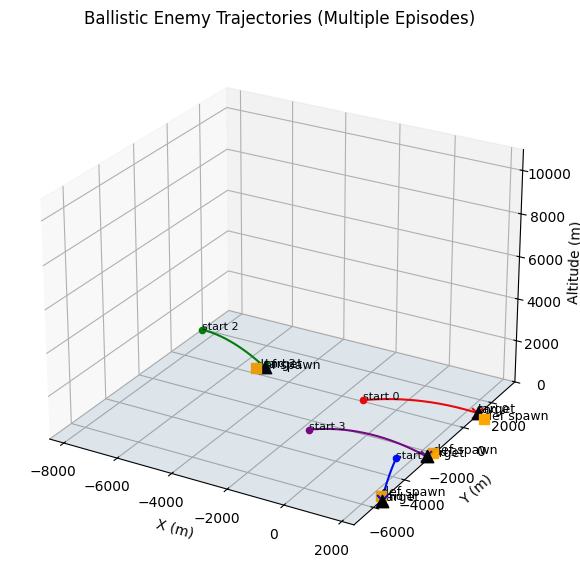

In [2]:
import matplotlib.pyplot as plt
import numpy as np

n_episodes = 4

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

colors = ["red","blue","green","purple"]

for ep in range(n_episodes):

    env = missile_interception_3d(enemy_mode="ballistic")
    obs,_ = env.reset(seed=ep)

    enemy_positions = []
    done = False

    while not done:
        enemy_positions.append(env.enemy_pos.copy())

        action = np.array([-1.0,1.0,0.0],dtype=np.float32)  # zero thrust
        obs,reward,terminated,truncated,info = env.step(action)
        done = terminated or truncated

    enemy_positions = np.array(enemy_positions)

    x = enemy_positions[:,0]
    y = enemy_positions[:,1]
    z = enemy_positions[:,2]

    c = colors[ep]

    # trajectory
    ax.plot(x,y,z,color=c,label=f"trajectory {ep}")

    # enemy start
    ax.scatter(x[0],y[0],z[0],color=c,marker="o")
    ax.text(x[0],y[0],z[0],f"start {ep}",fontsize=8)

    # enemy end
    ax.scatter(x[-1],y[-1],z[-1],color=c,marker="x",s=60)
    ax.text(x[-1],y[-1],z[-1],f"end {ep}",fontsize=8)

    # target
    tx = env.attack_target_x
    ty = env.attack_target_y
    tz = 0.0

    ax.scatter(tx,ty,tz,color="black",marker="^",s=80)
    ax.text(tx,ty,tz,"target",fontsize=9)

    # defense spawn
    dx = env.defense_launch_x
    dy = env.defense_launch_y
    dz = 0.0

    ax.scatter(dx,dy,dz,color="orange",marker="s",s=60)
    ax.text(dx,dy,dz,"def spawn",fontsize=9)

    # -----------------------------
    # TEXT DIAGNOSTICS
    # -----------------------------
    enemy_launch = np.array([x[0],y[0],z[0]])
    enemy_target = np.array([tx,ty,tz])
    defense_spawn = np.array([dx,dy,dz])

    dist_enemy_target = np.linalg.norm(enemy_launch - enemy_target)
    dist_def_enemy = np.linalg.norm(defense_spawn - enemy_launch)
    dist_def_target = np.linalg.norm(defense_spawn - enemy_target)

    print("\n==============================")
    print(f"Episode {ep}")
    print("------------------------------")
    print("Enemy launch:   ", enemy_launch)
    print("Enemy target:   ", enemy_target)
    print("Defense spawn:  ", defense_spawn)
    print("")
    print(f"Enemy → Target distance:  {dist_enemy_target:8.2f} m")
    print(f"Defense → Enemy distance: {dist_def_enemy:8.2f} m")
    print(f"Defense → Target distance:{dist_def_target:8.2f} m")
    print("==============================")

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Altitude (m)")
ax.set_title("Ballistic Enemy Trajectories (Multiple Episodes)")

# ======================================
# FORCE EQUAL AXIS SCALE
# ======================================

all_x = []
all_y = []
all_z = []

for line in ax.get_lines():
    xdata, ydata, zdata = line._verts3d
    all_x.extend(xdata)
    all_y.extend(ydata)
    all_z.extend(zdata)

all_x = np.array(all_x)
all_y = np.array(all_y)
all_z = np.array(all_z)

max_range = max(
    np.ptp(all_x),
    np.ptp(all_y),
    np.ptp(all_z)
)

mid_x = (all_x.max() + all_x.min()) / 2
mid_y = (all_y.max() + all_y.min()) / 2

ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
ax.set_ylim(mid_y - max_range/2, mid_y + max_range/2)

# ground is always z = 0
ax.set_zlim(0, max_range)

# faint ground plane for reference
gx = np.linspace(mid_x - max_range/2, mid_x + max_range/2, 10)
gy = np.linspace(mid_y - max_range/2, mid_y + max_range/2, 10)
gx, gy = np.meshgrid(gx, gy)
gz = np.zeros_like(gx)
ax.plot_surface(gx, gy, gz, alpha=0.1)

ax.view_init(elev=25, azim=-60)

plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML, display
from stable_baselines3 import PPO


# ==========================================
# SINGLE EPISODE RUNNER (trajectories + geometry recorded externally)
# ==========================================
def run_episode(env, episode_id, policy="zero", seed=None, model=None):

    obs, _ = env.reset(seed=seed)
    done = False

    enemy_traj = []
    defense_traj = []

    enemy_launch = env.enemy_pos.copy()
    defense_launch = env.defense_pos.copy()
    target = np.array([
        getattr(env, "attack_target_x", 0.0),
        getattr(env, "attack_target_y", 0.0),
        0.0
    ])

    print(f"\nEPISODE {episode_id}")
    print(f"{'TIME':<8} | {'ALT':<10} | {'SPEED':<10} | {'STATUS'}")
    print("-" * 50)

    step_count = 0

    while not done:

        enemy_traj.append(env.enemy_pos.copy())
        defense_traj.append(env.defense_pos.copy())

        if policy == "zero":
            action = np.array([-1.0, 1.0, 0.0], dtype=np.float32)
        elif policy == "pronav":
            action = env.calculate_pronav()
        elif policy == "ppo":
            action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        speed = np.linalg.norm(env.defense_vel)
        alt = env.defense_pos[2]

        if step_count % 10 == 0:
            print(f"{env.t:<8.2f} | {alt:<10.1f} | {speed:<10.1f} | {info['event']}")

        step_count += 1

    print("-" * 50)
    print(f"FINAL RESULT: {info['event']} at t={env.t:.2f}s")

    enemy_traj = np.array(enemy_traj)
    defense_traj = np.array(defense_traj)

    enemy_end = enemy_traj[-1]
    defense_end = defense_traj[-1]

    meta = dict(
        enemy_launch=enemy_launch,
        defense_launch=defense_launch,
        target=target,
        enemy_end=enemy_end,
        defense_end=defense_end
    )

    return enemy_traj, defense_traj, meta



# ==========================================
# ANIMATION (trajectories + generator geometry: target box, enemy spawn, defense spawn)
# ==========================================
def animate_trajectories(enemy_path, defense_path, meta, env, pronav=None, ppo=None):

    xe, ye, ze = enemy_path[:,0], enemy_path[:,1], enemy_path[:,2]
    xd, yd, zd = defense_path[:,0], defense_path[:,1], defense_path[:,2]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    time_text = ax.text2D(
        0.02, 0.95, "",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.6)
    )

    # ==========================================
    # equal scale axes
    # ==========================================
    all_x = np.concatenate([xe, xd])
    all_y = np.concatenate([ye, yd])
    all_z = np.concatenate([ze, zd])
    if pronav is not None:
        all_x = np.concatenate([all_x, pronav[:,0]])
        all_y = np.concatenate([all_y, pronav[:,1]])
        all_z = np.concatenate([all_z, pronav[:,2]])
    if ppo is not None:
        all_x = np.concatenate([all_x, ppo[:,0]])
        all_y = np.concatenate([all_y, ppo[:,1]])
        all_z = np.concatenate([all_z, ppo[:,2]])

    max_range = max(np.ptp(all_x), np.ptp(all_y), np.ptp(all_z))
    cx = np.mean(all_x)
    cy = np.mean(all_y)
    cz = np.mean(all_z)

    ax.set_xlim(cx - max_range/2, cx + max_range/2)
    ax.set_ylim(cy - max_range/2, cy + max_range/2)
    ax.set_zlim(0, cz + max_range/2)

    # ==========================================
    # GENERATOR GEOMETRY
    # ==========================================

    tgt = meta["target"]

    theta = env.enemy_theta
    g = env.g

    range_max = getattr(env, "range_max_used", env.range_easy_max)
    vmin = np.sqrt((env.range_min * g) / np.sin(2*theta))
    vmax = np.sqrt((range_max * g) / np.sin(2*theta))

    rmin = (vmin**2 * np.sin(2*theta)) / g
    rmax = (vmax**2 * np.sin(2*theta)) / g

    angles = np.linspace(0, 2*np.pi, 200)

    # enemy possible spawn ring
    ex_outer = tgt[0] + rmax*np.cos(angles)
    ey_outer = tgt[1] + rmax*np.sin(angles)
    ex_inner = tgt[0] + rmin*np.cos(angles)
    ey_inner = tgt[1] + rmin*np.sin(angles)

    ax.plot(ex_outer, ey_outer, np.zeros_like(ex_outer),
            color="blue", linestyle="--", alpha=0.4, label="Enemy spawn max")
    ax.plot(ex_inner, ey_inner, np.zeros_like(ex_inner),
            color="blue", linestyle=":", alpha=0.4, label="Enemy spawn min")

    # defense spawn ring
    r_def_min = 200
    r_def_max = 800

    dx_outer = tgt[0] + r_def_max*np.cos(angles)
    dy_outer = tgt[1] + r_def_max*np.sin(angles)
    dx_inner = tgt[0] + r_def_min*np.cos(angles)
    dy_inner = tgt[1] + r_def_min*np.sin(angles)

    ax.plot(dx_outer, dy_outer, np.zeros_like(dx_outer),
            color="red", linestyle="--", alpha=0.4, label="Defense spawn max")
    ax.plot(dx_inner, dy_inner, np.zeros_like(dx_inner),
            color="red", linestyle=":", alpha=0.4, label="Defense spawn min")

    # target box
    tx0 = env.targetbox_x_min
    tx1 = env.targetbox_x_max
    ty0 = env.targetbox_y_min
    ty1 = env.targetbox_y_max

    box_x = [tx0, tx1, tx1, tx0, tx0]
    box_y = [ty0, ty0, ty1, ty1, ty0]

    ax.plot(box_x, box_y, [0]*5, color="black", alpha=0.5, label="Target box")

    # ==========================================
    # trajectories
    # ==========================================

    line_enemy, = ax.plot([],[],[], 'b-', linewidth=2, label="Enemy")
    line_defense, = ax.plot([],[],[], 'r-', linewidth=2, label="Zero-control interceptor")
    line_pronav, = ax.plot([],[],[], color="orange", linewidth=2, label="ProNav interceptor")
    line_ppo, = ax.plot([],[],[], color="magenta", linewidth=2, label="PPO interceptor")

    xp = yp = zp = np.array([])
    if pronav is not None:
        xp, yp, zp = pronav[:,0], pronav[:,1], pronav[:,2]
    xp2 = yp2 = zp2 = np.array([])
    if ppo is not None:
        xp2, yp2, zp2 = ppo[:,0], ppo[:,1], ppo[:,2]

    el = meta["enemy_launch"]
    dl = meta["defense_launch"]
    ee = meta["enemy_end"]
    de = meta["defense_end"]

    ax.scatter(*el, color="blue", marker="o", s=80)
    ax.text(*el, "Enemy launch")

    ax.scatter(*dl, color="red", marker="^", s=80)
    ax.text(*dl, "Defense launch")

    ax.scatter(*tgt, color="black", marker="*", s=120)
    ax.text(*tgt, "Target")

    ax.scatter(*ee, color="cyan", marker="x", s=80)
    ax.scatter(*de, color="orange", marker="x", s=80)

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Altitude (m)")
    ax.set_title("Missile Interception Geometry + Spawn Regions")

    ax.legend()

    total = len(xe)
    if pronav is not None:
        total = max(total, len(pronav))
    if ppo is not None:
        total = max(total, len(ppo))

    def update(frame):
        line_enemy.set_data_3d(xe[:frame], ye[:frame], ze[:frame])
        line_defense.set_data_3d(xd[:frame], yd[:frame], zd[:frame])
        if pronav is not None:
            line_pronav.set_data_3d(xp[:frame], yp[:frame], zp[:frame])
        if ppo is not None:
            line_ppo.set_data_3d(xp2[:frame], yp2[:frame], zp2[:frame])
        sim_time = frame * env.dt_sim
        time_text.set_text(f"t = {sim_time:.2f} s\nstep = {frame}")
        ax.view_init(elev=25, azim=-60 + frame*0.3)
        artists = [line_enemy, line_defense, time_text]
        if pronav is not None:
            artists.append(line_pronav)
        if ppo is not None:
            artists.append(line_ppo)
        return artists

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=total,
        interval=30
    )

    plt.close(fig)
    return HTML(ani.to_html5_video())



# ==========================================
# RUN SAME SCENARIO WITH 3 POLICIES (zero, pronav, ppo)
# ==========================================
env = missile_interception_3d(enemy_mode="ballistic")

model = PPO.load("/home/t/Downloads/Missile-Interception-System/(v4)_physics_approach/(v4.1)_physic_approach_reimagined/ppo_missile_radius5_23M.zip")

enemy_zero, defense_zero, meta = run_episode(env, 1, policy="zero", seed=0)
enemy_pronav, defense_pronav, _ = run_episode(env, 2, policy="pronav", seed=0)
enemy_ppo, defense_ppo, _ = run_episode(env, 3, policy="ppo", seed=0, model=model)


# ==========================================
# SHOW ANIMATION (Enemy + Zero-control + ProNav + PPO)
# ==========================================
print("\nRendering: Enemy + Zero-control + ProNav + PPO")
display(animate_trajectories(
    enemy_zero,
    defense_zero,
    meta,
    env,
    pronav=defense_pronav,
    ppo=defense_ppo
))


EPISODE 1
TIME     | ALT        | SPEED      | STATUS
--------------------------------------------------
0.10     | 33.7       | 799.6      | running
1.10     | 365.4      | 795.5      | running
2.10     | 687.3      | 791.5      | running
3.10     | 999.4      | 787.6      | running
4.10     | 1301.7     | 783.9      | running
5.10     | 1594.2     | 780.2      | running
6.10     | 1876.9     | 776.6      | running
7.10     | 2149.7     | 773.1      | running
8.10     | 2412.8     | 769.8      | running
9.10     | 2666.0     | 766.6      | running
10.10    | 2909.4     | 763.4      | running
11.10    | 3143.1     | 760.4      | running
12.10    | 3366.9     | 757.5      | running
13.10    | 3580.9     | 754.7      | running
14.10    | 3785.1     | 752.1      | running
--------------------------------------------------
FINAL RESULT: enemy_ground at t=15.00s

EPISODE 2
TIME     | ALT        | SPEED      | STATUS
--------------------------------------------------
0.10     | 32.1       |

In [4]:
import os
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


class HitLogger(BaseCallback):
    def _on_step(self):
        infos = self.locals.get("infos", [])
        for info in infos:
            if "hit" in info:
                if info["hit"]:
                    print("HIT")
                else:
                    print("MISS")

                if self.logger is not None:
                    for key in ("min_dist", "dca_pos_ratio", "vclose_pos_ratio"):
                        if key in info and np.isfinite(info[key]):
                            self.logger.record(
                                f"rollout/{key}",
                                float(info[key]),
                                exclude="stdout",
                            )
        return True


log_dir = "./ppo_missile_tensorboard/"
os.makedirs(log_dir, exist_ok=True)


vec_env = DummyVecEnv([
    lambda: Monitor(
        missile_interception_3d(enemy_mode="ballistic"),  # constant-velocity targets (lead pursuit)
        info_keywords=("min_dist", "dca_pos_ratio", "vclose_pos_ratio")
    )
])


# --------------------------------
# LOAD EXISTING MODEL
# --------------------------------

model = PPO.load(
    "ppo_missile_radius5_23M",
    env=vec_env,
    tensorboard_log=log_dir
)


# --------------------------------
# CONTINUE TRAINING (linear = learn intercept geometry)
# --------------------------------

model.learn(
    total_timesteps=3_000_000,
    tb_log_name="ppo_ball1_targets",
    callback=HitLogger()
)


# --------------------------------
# SAVE NEW MODEL
# --------------------------------

model.save("ppo_missile_ball_26M")

Logging to ./ppo_missile_tensorboard/ppo_ball1_targets_1


MISS
MISS
MISS
MISS
HIT
HIT
HIT
MISS
HIT
MISS
MISS
HIT
HIT
MISS
MISS
HIT
MISS
MISS
MISS
HIT
HIT
MISS
MISS
HIT
HIT
HIT
MISS
HIT
HIT
MISS
MISS
MISS
HIT
HIT
MISS
HIT
MISS
MISS
MISS
MISS
MISS
HIT
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 94.3     |
|    ep_rew_mean     | 0.429    |
| time/              |          |
|    fps             | 1086     |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 4096     |
---------------------------------
MISS
HIT
MISS
HIT
MISS


KeyboardInterrupt: 

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

N_TRAJ = 50
STEPS = 200

env = missile_interception_3d(enemy_mode="linear")

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

all_z = []

for i in range(N_TRAJ):

    obs, _ = env.reset(seed=i)

    traj = []

    for _ in range(STEPS):

        traj.append(env.enemy_pos.copy())

        # propagate enemy only
        dt = env.dt_sim
        env.enemy_pos += env.enemy_vel * dt

    traj = np.array(traj)

    ax.plot(
        traj[:,0],
        traj[:,1],
        traj[:,2],
        alpha=0.6
    )

    all_z.extend(traj[:,2])


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Enemy Linear Trajectories")

plt.show()

print("min z:", np.min(all_z))
print("max z:", np.max(all_z))

AssertionError: 